# Outlier Detection and Treatment

> **Chapter 1.3 — Data Exploration**

Outliers are data points that deviate significantly from the rest of a dataset. Left untreated, they distort statistical summaries, bias model training, and produce misleading conclusions.

**In this notebook you will:**
- Understand what outliers are and where they come from
- Apply the **IQR (Interquartile Range)** method to detect them
- Visualize outlier boundaries
- Choose and apply appropriate treatment strategies

---

## 1. What is an Outlier?

An **outlier** is an observation that lies an abnormal distance from the other values in a dataset. They arise from several sources:

| Source | Description |
|---|---|
| Measurement error | Faulty sensors, instrument drift |
| Data entry error | Typos, wrong units (e.g. feet entered as meters) |
| Natural variation | Rare but legitimate extreme events |
| Sampling issues | Observations from the wrong population |

### Types of Outliers

**Global outlier** — a point that is extreme relative to the *entire* dataset.
Example: a height of 40.2 ft when everyone else is ~5–7 ft.

**Contextual outlier** — normal globally but anomalous *in context*.
Example: 30 °C temperature in January.

**Collective outlier** — a *group* of points that are anomalous together, though each individual point may look fine.

### Why Do Outliers Matter?

- The **mean** is pulled toward extreme values; the **median** is not.
- The **standard deviation** is inflated, making z-scores unreliable.
- **Regression** lines are distorted by high-leverage points.
- Distance-based models (k-NN, k-Means) cluster incorrectly.

---

## 2. The Dataset

In [6]:
import pandas as pd

df = pd.DataFrame({
    "name": [
        "mohan", "maria", "sakib", "tao", "virat", "khusbu", "dmitry",
        "selena", "john", "imran", "jose", "deepika", "yoseph", "binod",
        "gulshan", "johnson", "donald", "aamir", "ken", "Liu"
    ],
    "height": [
        1.2, 2.3, 4.9, 5.1, 5.2, 5.4, 5.5,
        5.5, 5.6, 5.6, 5.8, 5.9, 6.0, 6.1,
        6.2, 6.5, 7.1, 14.5, 23.2, 40.2 # Heights in feet, some of them are outliers
    ]
})

df


,name,height
0,mohan,1.2
1,maria,2.3
2,sakib,4.9
3,tao,5.1
4,virat,5.2
5,khusbu,5.4
6,dmitry,5.5
7,selena,5.5
8,john,5.6
9,imran,5.6


---

## 3. The IQR Method

The **Interquartile Range (IQR)** measures the spread of the middle 50% of the data, making it robust to the very outliers we are trying to find.

### Quartiles

Sorting the data and splitting it into four equal parts gives us:

$$Q_1 = \text{25th percentile} \quad Q_2 = \text{median} \quad Q_3 = \text{75th percentile}$$

### IQR Definition

$$\boxed{IQR = Q_3 - Q_1}$$

### Tukey Fences

Any observation outside these bounds is flagged as an outlier:

$$\text{Lower fence} = Q_1 - 1.5 \times IQR$$

$$\text{Upper fence} = Q_3 + 1.5 \times IQR$$

The constant **1.5** is the standard Tukey rule (1977). Use **3.0** to flag only *extreme* outliers.

### Why Not Use the Mean ± 3σ Rule?

The z-score method computes:

$$z = \frac{x - \bar{x}}{\sigma}$$

Both $\bar{x}$ and $\sigma$ are sensitive to outliers — so the outlier inflates the very measure used to detect it. IQR avoids this because $Q_1$ and $Q_3$ are **resistant statistics**.

> **Rule of thumb:** Use IQR for skewed data or when you suspect extreme values. Use z-score only on approximately normal distributions.

In [3]:
Q1 = df["height"].quantile(0.25)
Q3 = df["height"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Q1        : {Q1}")
print(f"Q3        : {Q3}")
print(f"IQR       : {IQR}")
print(f"Lower fence: {lower:.2f}")
print(f"Upper fence: {upper:.2f}")

outliers = df[(df["height"] < lower) | (df["height"] > upper)]
print(f"\nOutliers ({len(outliers)} found):")
print(outliers.to_string(index=False))


Q1        : 5.3500000000000005
Q3        : 6.275
IQR       : 0.9249999999999998
Lower fence: 3.96
Upper fence: 7.66

Outliers (5 found):
 name  height
mohan     1.2
maria     2.3
aamir    14.5
  ken    23.2
  Liu    40.2


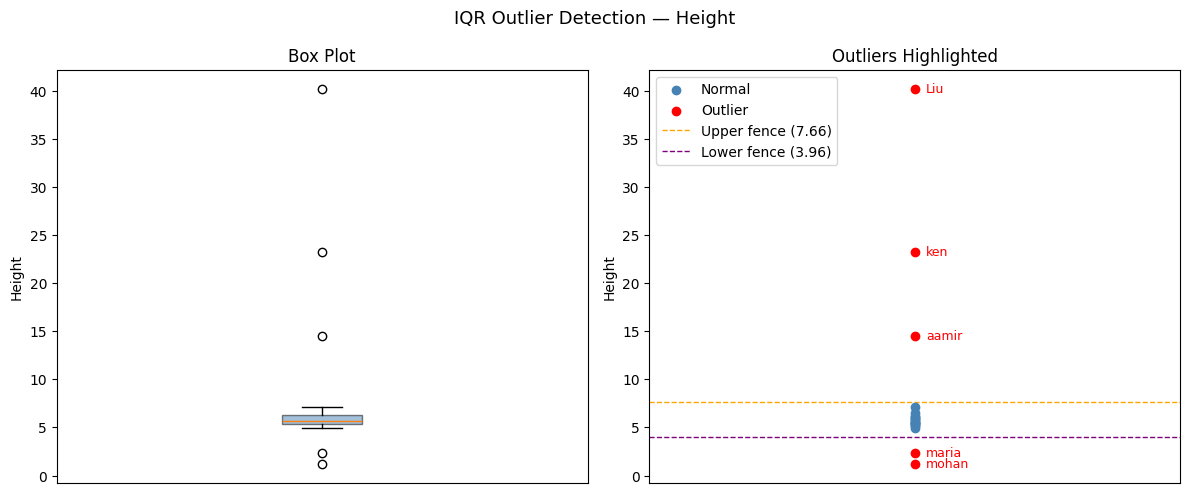

In [5]:
import matplotlib.pyplot as plt

is_outlier = (df["height"] < lower) | (df["height"] > upper)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Box plot ---
ax1.boxplot(df["height"], vert=True, patch_artist=True,
            boxprops=dict(facecolor="steelblue", alpha=0.5))
ax1.set_title("Box Plot")
ax1.set_ylabel("Height")
ax1.set_xticks([])

# --- Strip plot: outliers in red, normal in steelblue ---
ax2.scatter([1] * (~is_outlier).sum(), df.loc[~is_outlier, "height"],
            color="steelblue", zorder=3, label="Normal")
ax2.scatter([1] * is_outlier.sum(), df.loc[is_outlier, "height"],
            color="red", zorder=4, label="Outlier")
for _, row in df[is_outlier].iterrows():
    ax2.annotate(row["name"], (1, row["height"]),xytext=(8, 0), textcoords="offset points", va="center", fontsize=9, color="red")
ax2.axhline(upper, color="orange", linestyle="--", linewidth=1, label=f"Upper fence ({upper:.2f})")
ax2.axhline(lower, color="purple", linestyle="--", linewidth=1, label=f"Lower fence ({lower:.2f})")
ax2.set_title("Outliers Highlighted")
ax2.set_ylabel("Height")
ax2.set_xticks([])
ax2.legend(loc="upper left")

plt.suptitle("IQR Outlier Detection — Height", fontsize=13)
plt.tight_layout()
plt.show()


---

## 5. Outlier Treatment

Once detected, you have four options. The right choice depends on **why** the outlier exists.

| Strategy | When to use | How |
|---|---|---|
| **Remove** | Confirmed data error with no recoverable value | Drop the row |
| **Cap (Winsorize)** | Value is implausible but row is otherwise useful | Replace with the fence value |
| **Impute** | Missing-at-random or measurement error | Replace with median / model prediction |
| **Keep** | Legitimate rare event | Document and retain |

> **Never remove an outlier just because it is inconvenient.** Always investigate the cause first.

In [ ]:
# --- Strategy 1: Remove outliers ---
df_removed = df[~is_outlier].copy()
print(f"Rows after removal: {len(df_removed)}  (dropped {is_outlier.sum()})")

# --- Strategy 2: Cap (Winsorize) to fence values ---
df_capped = df.copy()
df_capped["height"] = df_capped["height"].clip(lower=lower, upper=upper)
print(f"\nCapped heights (outlier rows):")
print(df_capped[is_outlier][["name", "height"]].to_string(index=False))

# --- Compare mean before / after each treatment ---
print(f"\nMean height — original : {df['height'].mean():.2f}")
print(f"Mean height — removed  : {df_removed['height'].mean():.2f}")
print(f"Mean height — capped   : {df_capped['height'].mean():.2f}")
print(f"Median (unaffected)    : {df['height'].median():.2f}")